In [1]:
from astropy.cosmology import Planck18 as cosmo
from astropy.cosmology import z_at_value
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from synthesizer import Galaxy
from synthesizer.parametric import SFH, Stars, ZDist
from synthesizer.grid import Grid
from synthpop.distribution_functions import Schechter
from synthpop.galaxy_population import GalaxyPopulation
from synthpop.universe import Universe
from unyt import yr, Myr, Msun, Gyr, unyt_quantity, Mpc, dimensionless, deg, sr, arcminute


In [2]:

# Define the galaxy stellar mass function (GSMF) using a Schechter function
x_star = 10**10.745 * Msun     
phi_star = 10**(-2.437) * Mpc**-3  
alpha = -1.465
gsmf = Schechter(x_star=x_star, alpha=alpha, phi_star=phi_star)

In [3]:
# load grid
grid = Grid("test_grid")

In [4]:

# Define a delta function for metallicity
metal_dist_function = ZDist.DeltaConstant

metal_dist_parameters = {
    "log10metallicity": -2.5
}

# Define a constant star formation history (SFH)
sfh_function = SFH.Constant

sfh_parameters = {
    "max_age": cosmo.age(0.0).to("Myr").value * Myr
}

9755.714523185221 Mpc**(-3) 9803
2.845691382765531 11514.286016313792 Myr 5363631316.739245
6.372745490981964 12927.179512035478 Myr 8508631582.640564
3.3867735470941884 11918.02539427223 Myr 1236472235.0537176
4.428857715430862 12427.173339334848 Myr 3573602246.065781
4.248496993987976 12356.738457481988 Myr 1096680598.3368697
4.028056112224449 12262.067006724199 Myr 6332908400.455102
7.735470941883767 13120.378567546872 Myr 1739726432.3437989
9.298597194388778 13266.397431572197 Myr 11752771174.629477
1.8036072144288577 10169.968565241903 Myr 10716676480.328644
3.7074148296593186 12104.50264637783 Myr 10618229410.993824
0.8016032064128256 7035.913221448177 Myr 1407008085.6026864
1.6432865731462925 9847.549689785119 Myr 1615908753.8959157
4.488977955911824 12449.38192204813 Myr 1890397377.8192234
1.56312625250501 9668.49303868056 Myr 2635370519.267393
9.218436873747494 13260.249556429373 Myr 1998026308.5725508
8.71743486973948 13218.928712704426 Myr 1557344772.926135
5.290581162324649

/Users/sw376/Dropbox/Research/projects/synthpop/venv/lib/python3.10/site-packages/unyt/array.py:1900: RuntimeWarning: divide by zero encountered in log10
  out_arr = func(np.asarray(inp), out=out_func, **kwargs)


3.8276553106212425 12166.624495371352 Myr 3883098049.059609
5.370741482965932 12716.719031495884 Myr 2539859068.7807293
3.6873747494989977 12093.765305220919 Myr 11119677311.206978
1.56312625250501 9668.49303868056 Myr 1236472235.0537176
2.344689378757515 10993.584899070358 Myr 1821885343.4651651
9.839679358717435 13304.951167643627 Myr 1855825227.755519
8.176352705410821 13167.884437840254 Myr 1646011502.3085496
1.7034068136272544 9973.728717354814 Myr 3573602246.065781
1.4028056112224447 9268.431645464516 Myr 13129145852.124653
2.9458917835671343 11599.35469658839 Myr 14531975242.368954
8.537074148296593 13202.716177278608 Myr 1446507338.5216472
9.238476953907815 13261.797802306459 Myr 3955436244.7347097
2.5851703406813624 11265.596867610237 Myr 1037605019.7669096
9.759519038076151 13299.544253172968 Myr 9245531098.23358
3.006012024048096 11647.906246962666 Myr 7074559422.819879
5.831663326653306 12823.081122543419 Myr 1202708334.7685096
3.8076152304609217 12156.537090354495 Myr 6274

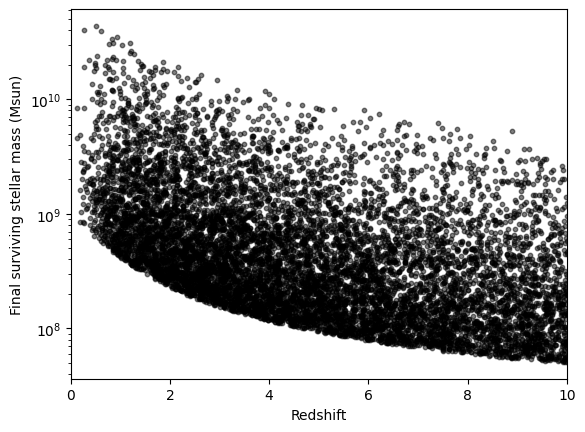

In [5]:
# Define the star formation and metallicity histories for the galaxies in the population

# Instantiate the galaxy population
universe = Universe(
    galaxy_stellar_mass_function=gsmf, 
    minimum_stellar_mass=1E9*Msun, 
    maximum_stellar_mass=1E11*Msun,
    sfh_function=sfh_function,
    sfh_parameters=sfh_parameters,
    metal_dist_function=metal_dist_function,
    metal_dist_parameters=metal_dist_parameters, 
    cosmology=cosmo,
    grid=grid,
    solid_angle=10*arcminute**2,
    random_seed=42)

print(universe)

universe.plot_redshift_surviving_mass()
